# Pauta Auxiliar 09: Heapsort, Radix Sort, Mergesort y Grafos

**Auxiliares: Daniela Espinoza, Cristián Llull Torres, Benjamín Osses,
Anish Samtani y Marcelo Zamorano<br>
Profesores: Nelson Baloian, Iván Sipirán, Patricio Poblete<br>
Curso: CC3001 Algoritmos y Estructuras de Datos**

# Pregunta 1: Radix Sort

Radixsort (relacionado con Bucketsort) al no estar basado en comparaciones, logra ordenar un conjunto en orden lineal. Esto lo realiza mediante “pasadas” de ordenación a través de los elementos que se quieren ordenar. Para ello, se agrupan los elementos en una matriz de tal manera que todos tengan la misma cantidad de subelementos. Si no son todos del mismo largo, se añade algún subelemento que no afecte a la ordenación, o más bien sea coherente con ella (ej: zero-padding).

Para efectuar una pasada, se debe elegir alguna columna para clasificar, de tal manera de ingresar en un bucket cada elemento según su valor en esa columna. Por ejemplo, al ordenar los números `[99046, 82149, 70471, 94171]`
en orden creciente según sus valores en la columna 2 (contando de derecha a izquierda, es decir su tercer dígito), se agrupan en distintas colas:

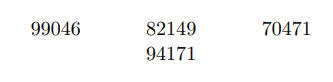

Para completar la ordenación, se concatenan las k colas y se forma nuevamente una sola con todos los elementos. Repitiendo esta operación por cada dígito, de derecha a izquierda, al finalizar la pasada por la última columna, se tendrán los elementos ordenados.

Implemente la función `radixsort(a)` que ordene arreglos de strings numéricos, utilizando una lista de 10 colas.




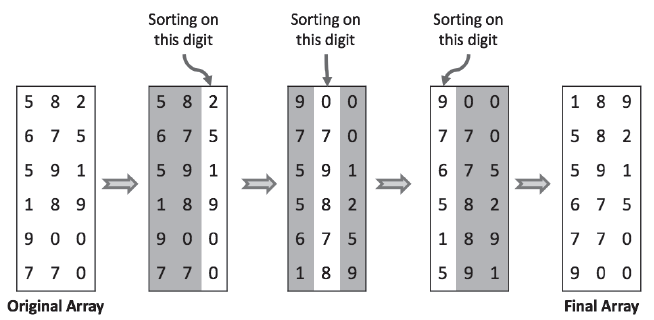

In [ ]:
def sort_column(arr: list[str], column: int):
    """Ordena una lista de números por columna"""

    # Lista de buckets. Un bucket por cada número de 0 a 9.
    buckets = [[] for _ in range(10)]

    # Agregar cada número al bucket que le corresponde.
    for num in arr:
        pos = int(num[column])
        buckets[pos].append(num)

    # Sacar los elementos en orden, desde el primer bucket al último.
    output = []
    for bucket in buckets:
        for num in bucket:
            output.append(num)

    # Mutar la lista original,
    # para que tenga los elementos con el nuevo orden
    for i in range(len(arr)):
        arr[i] = output[i]


def radixsort(arr: list[str]):
    """Implementacion de radixsort"""
    max_len = max([len(num) for num in arr])

    # zero padding
    for i in range(len(arr)):
        arr[i] = arr[i].zfill(max_len)

    # Ordenar cada columna, de derecha a izquierda.
    for column in range(max_len - 1, -1, -1):
        sort_column(arr, column)

    # remove zero padding
    for i in range(len(arr)):
        arr[i] = arr[i].lstrip("0")


In [ ]:
from random import randint

def check_sort(arr: list[str]):
    """Comprueba si la lista está ordenada"""
    for i in range(len(arr) - 1):
        if int(arr[i]) > int(arr[i + 1]):
            return False
    return True

# Probar con varios casos aleatorios
for _ in range(150):
    # Una lista de elementos aleatorios
    arr = [str(randint(0, 1_000_000)) for _ in range(1_000)]
    # Ordenar y comprobar
    radixsort(arr)
    assert check_sort(arr)

# Un caso de prueba más pequeño
arr = ["720", "200", "300", "23", "42", "3", "1000"]
radixsort(arr)
check_sort(arr)
print(arr)

['3', '23', '42', '200', '300', '720', '1000']


# Pregunta 2: Multiway Merge

Es conocido el algoritmo de _merge sort_, el cual divide un arreglo en 2 partes iguales, ordena recursivamente y luego recursivamente y luego realiza la operación de _merge_ para unir ordenadamente cada subarreglo.

a) Programe una función una función de _merge_k_ que dado $k$ arreglos ordenados $(a_0,...,a_{k-1} : \sum_{i=0}^{k-1}|a_i| = n)$ vaya entregando los elementos del arreglo ordenado restante. ¿Qué orden asintótico es?

## Implementación Naive

In [ ]:
"""
Input: k arreglos ordenados
Output: Un arreglo ordenado de los k unidos
"""
def merge_k(k_arreglos: list[list[int]]) -> list[int]:
    k = len(k_arreglos)
    # Para cada lista mantenemos un puntero de la posición que se inspecciona
    # partiendo por 0. Una vez que terminemos con una lista marcamos con -1
    k_punteros = []
    for arreglo in k_arreglos:
        if len(arreglo) > 0:
            k_punteros.append(0)
        else:
            k_punteros.append(-1)

    resultado = []
    listo = False

    while not listo:
        listo = True

        # Buscamos el minimo de todas las listas en la posición del puntero
        minimo_valor = float('inf')
        indice_minimo = -1
        for i in range(k):
            puntero_i = k_punteros[i]
            if puntero_i == -1:
                continue
            listo = False # Puede haber elemento en este arreglo para la prox ronda
            a_i = k_arreglos[i]
            if a_i[puntero_i] < minimo_valor:
                minimo_valor = a_i[puntero_i]
                indice_minimo = i

        if indice_minimo != -1:
            puntero = k_punteros[indice_minimo]
            arreglo = k_arreglos[indice_minimo]

            resultado.append(arreglo[puntero])

            if puntero + 1 < len(arreglo): # si quedan elementos avanzo puntero
                k_punteros[indice_minimo] += 1
            else:
                k_punteros[indice_minimo] = -1

    return resultado

In [ ]:
# Ejemplo
res = merge_k([
    [1, 50, 100, 200],
    [10, 52, 60, 145],
    [4, 100, 500]
])
assert res == [1, 4, 10, 50, 52, 60, 100, 100, 145, 200, 500]
res

[1, 4, 10, 50, 52, 60, 100, 100, 145, 200, 500]

Si hay k arreglos y n elementos en total:
Esta solución no es optima dado que tiene orden $O(nk)$, pues en cada iteración se revisan todas las listas para obtener el menor.

Una mejora natural, es en vez de inspeccionar todos los arreglos por cada elemento a insertar en el resultado, mantener un heap con los elementos de la posición del puntero de cada arreglo, esto reduce el costo de búsqueda del mínimo a extraerlo de un heap con k elemento que es del ordern $O(\log k)$, resultando en una cota mejorada $O(n\log k)$.

In [ ]:
# Para el Heap modificamos la implementación del apunte de max heap a min heap
import numpy as np

def trepar_min(a, j):
    while j >= 1 and a[j] < a[(j-1)//2]:
        (a[j], a[(j-1)//2]) = (a[(j-1)//2], a[j])
        j = (j-1)//2

def hundir_min(a, j, n):
    while 2*j + 1 < n:
        k = 2*j + 1

        # Elegir el menor hijo
        if k + 1 < n and a[k+1] < a[k]:
            k += 1

        # Ya está en la posición correcta
        if a[j] <= a[k]:
            break

        (a[j], a[k]) = (a[k], a[j])
        j = k

class MinHeap:
    def __init__(self, maxn=100):
        self.a = np.empty(maxn, dtype=object)
        self.n = 0

    def insert(self, x):
        assert self.n < len(self.a)
        self.a[self.n] = x
        trepar_min(self.a, self.n)
        self.n += 1

    def extract_min(self):
        assert self.n > 0

        x = self.a[0]

        self.n -= 1

        if self.n > 0:
            self.a[0] = self.a[self.n]
            hundir_min(self.a, 0, self.n)

        return x

    def vacio(self):
        return self.n == 0

    def imprimir(self):
        print(self.a[:self.n])


In [ ]:

"""
Input: k arreglos ordenados
Output: Un arreglo ordenado de los k unidos
"""
def merge_k(k_arreglos):
    resultado = []

    # Podemos facilitar manteniendo en el heap por elemento su valor
    # indice del arreglo (de los k) y indice dentro del arreglo
    heap = MinHeap(sum(len(a) for a in k_arreglos) + 1)
    for i, arreglo in enumerate(k_arreglos):
        if arreglo: # Si hay arreglo metemos su primer elemento
            heap.insert((arreglo[0], i, 0))

    while not heap.vacio():
        valor, i, pos = heap.extract_min()
        resultado.append(valor)

        # Del arreglo que se uso el mínimo, metemos el siguiente elemento
        # si es que hay más
        if pos + 1 < len(k_arreglos[i]):
            heap.insert((k_arreglos[i][pos + 1], i, pos + 1))

    return resultado

In [ ]:
# Ejemplo
res = merge_k([
    [1, 50, 100, 200],
    [10, 52, 60, 145],
    [4, 100, 500]
])
assert res == [1, 4, 10, 50, 52, 60, 100, 100, 145, 200, 500]
res

[1, 4, 10, 50, 52, 60, 100, 100, 145, 200, 500]

# Pregunta 3: Determinar si un grafo tiene ciclos

Sea $G = (V ,E )$ un grafo dirigido o no dirigido con $n$ vértices y $m$ aristas. Determine un algoritmo en palabras para revisar si este tiene algún ciclo. Puede asumir que es conexo.

R: Asumiremos que $G$ es conexo. Podemos aplicar DFS en $G$. Se puede ir marcando los nodos por los que vayamos pasando. Si en algún momento encontramos un nodo por el que ya habíamos pasado, significa que encontramos un ciclo. $G$ no tiene ciclos si no encontramos ninguno, es decir, es un árbol.



# P4: Grafos

In [ ]:
# Originalmente tomado de GeeksForGeeks

from collections import defaultdict

# This class represents a directed graph
# using adjacency list representation
class Graph:

    # Constructor
    def __init__(self):

        # Default dictionary to store graph
        self.graph = defaultdict(list)

    # Function to add an edge to graph
    def addEdge(self, u, v):
        self.graph[u].append(v)

    # Function to print a BFS of graph
    def BFS(self, s):

        # Mark all the vertices as not visited
        visited = [False] * (max(self.graph) + 1)

        # Create a queue for BFS
        queue = []

        # Mark the source node as
        # visited and enqueue it
        queue.append(s)
        visited[s] = True

        while queue:

            # Dequeue a vertex from
            # queue and print it
            s = queue.pop(0)
            print(s, end=" ")

            # Get all adjacent vertices of the
            # dequeued vertex s.
            # If an adjacent has not been visited,
            # then mark it visited and enqueue it
            for i in self.graph[s]:
                if not visited[i]:
                    queue.append(i)
                    visited[i] = True

    # A function used by DFS
    def DFSUtil(self, v, visited):

        # Mark the current node as visited
        # and print it
        visited.add(v)
        print(v, end=' ')

        # Recur for all the vertices
        # adjacent to this vertex
        for neighbour in self.graph[v]:
            if neighbour not in visited:
                self.DFSUtil(neighbour, visited)


    # The function to do DFS traversal. It uses
    # recursive DFSUtil()
    def DFS(self, v):

        # Create a set to store visited vertices
        visited = set()

        # Call the recursive helper function
        # to print DFS traversal
        self.DFSUtil(v, visited)

In [ ]:
# Creamos el grafo:
# A:0, B:1, C:2, D:3, E:4, F:5, G:6
grafo = Graph()
grafo.addEdge(0, 5)
grafo.addEdge(0, 1)
grafo.addEdge(0, 2)
grafo.addEdge(0, 6)

grafo.addEdge(5, 4)
grafo.addEdge(5, 3)

grafo.addEdge(3, 4)
grafo.addEdge(6, 4)

In [ ]:
grafo.BFS(0)

0 5 1 2 6 4 3 

In [ ]:
grafo.DFS(0)

0 5 4 3 1 2 6 